In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("Python path:", sys.executable)
print("All imports successful")

Python path: /Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/.venv/bin/python
All imports successful


In [2]:
from pathlib import Path
import glob

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "datasets"
FIG_DIR = BASE_DIR / "figures"
SCALER_DIR = BASE_DIR / "scalers"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

for folder in [FIG_DIR, SCALER_DIR, OUTPUT_DIR, MODEL_DIR]:
    folder.mkdir(exist_ok=True)

print("Project folders ready.")

Project folders ready.


In [3]:
csv_files = sorted(glob.glob(str(DATA_DIR / "daily_solar_*.csv")))

print("Number of files:", len(csv_files))

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

solar_df = pd.concat(dfs, ignore_index=True)

solar_df["date"] = pd.to_datetime(solar_df["date"])
solar_df = solar_df.sort_values("date")

print("Dataset shape:", solar_df.shape)

solar_df.head()

Number of files: 18
Dataset shape: (6575, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


In [4]:
print("Columns:")
print(solar_df.columns)

print("\nDate Range:")
print(solar_df["date"].min(), "to", solar_df["date"].max())

print("\nBad quality counts:")
print(solar_df["bad_quality"].value_counts())

Columns:
Index(['date', 'solar_t', 'bad_quality'], dtype='str')

Date Range:
1996-01-01 00:00:00 to 2013-12-31 00:00:00

Bad quality counts:
bad_quality
0    5570
1    1005
Name: count, dtype: int64


In [5]:
total_rows = len(solar_df)

bad_rows = (solar_df["bad_quality"] == 1).sum()

clean_df = solar_df[solar_df["bad_quality"] == 0].copy()

removed_pct = (bad_rows / total_rows) * 100

print("Total rows:", total_rows)
print("Bad rows removed:", bad_rows)
print("Remaining rows:", len(clean_df))
print(f"Percentage removed: {removed_pct:.2f}%")

Total rows: 6575
Bad rows removed: 1005
Remaining rows: 5570
Percentage removed: 15.29%


## Part A — Data Preprocessing

This section implements the preprocessing pipeline required by the assignment:

- loaded all daily solar radiation files from 1996–2013
- removed rows where `bad_quality = 1`
- reported the percentage of rows removed
- produced the three required visualisations
- encoded day-of-year seasonality using Fourier sine/cosine features, with leap-year handling
- created 7-row backward-looking rolling statistics on the filtered dataset
- created lagged features from `t-1` to `t-7`
- created target variables from `t+1` to `t+7`
- used a temporal training/validation/test split
- dropped the first 7 rows of validation and test partitions after split boundaries to prevent leakage
- standardised features using a scaler fit on training data only
- saved the scaler for later hidden-set evaluation

In [6]:
solar_df = solar_df.sort_values("date").reset_index(drop=True)
clean_df = clean_df.sort_values("date").reset_index(drop=True)

print("solar_df shape:", solar_df.shape)
print("clean_df shape:", clean_df.shape)
clean_df.head()

solar_df shape: (6575, 3)
clean_df shape: (5570, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


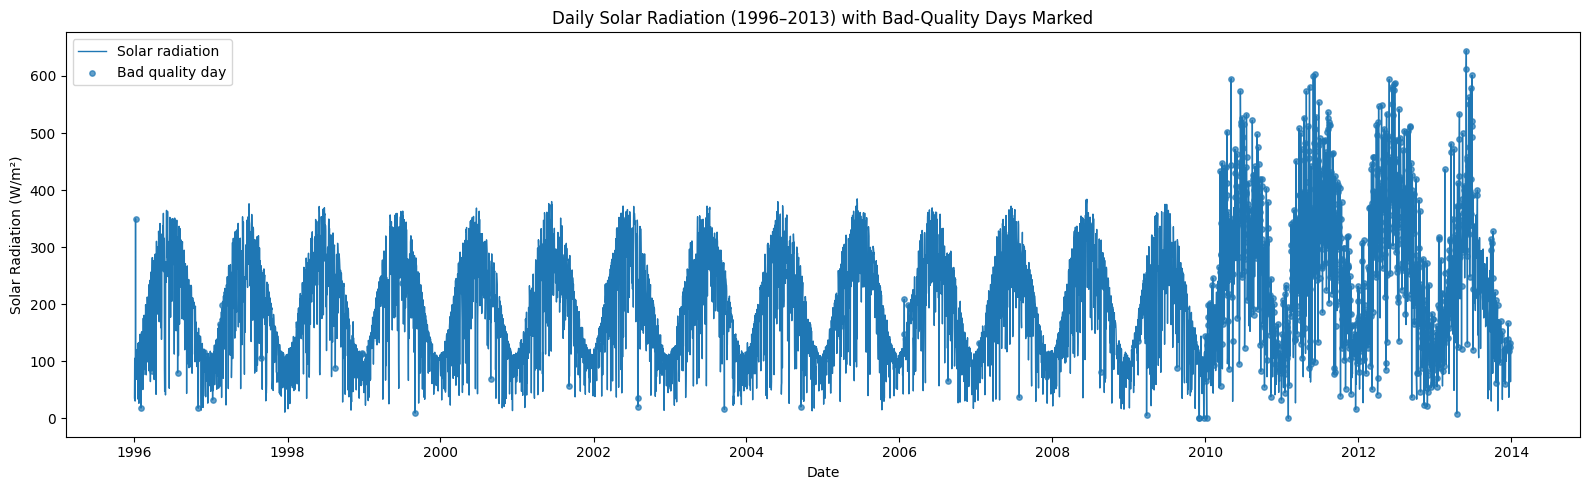

In [7]:
plt.figure(figsize=(16, 5))

plt.plot(
    solar_df["date"],
    solar_df["solar_t"],
    linewidth=1,
    label="Solar radiation"
)

bad_df = solar_df[solar_df["bad_quality"] == 1]

plt.scatter(
    bad_df["date"],
    bad_df["solar_t"],
    s=15,
    alpha=0.7,
    label="Bad quality day"
)

plt.title("Daily Solar Radiation (1996–2013) with Bad-Quality Days Marked")
plt.xlabel("Date")
plt.ylabel("Solar Radiation (W/m²)")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_timeseries_bad_quality.png", dpi=200)
plt.show()

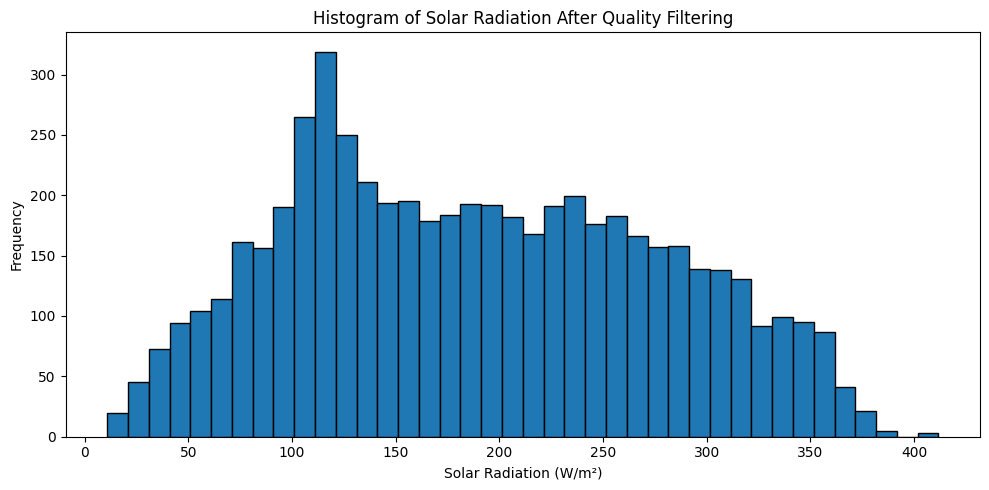

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(clean_df["solar_t"], bins=40, edgecolor="black")

plt.title("Histogram of Solar Radiation After Quality Filtering")
plt.xlabel("Solar Radiation (W/m²)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_histogram_filtered.png", dpi=200)
plt.show()

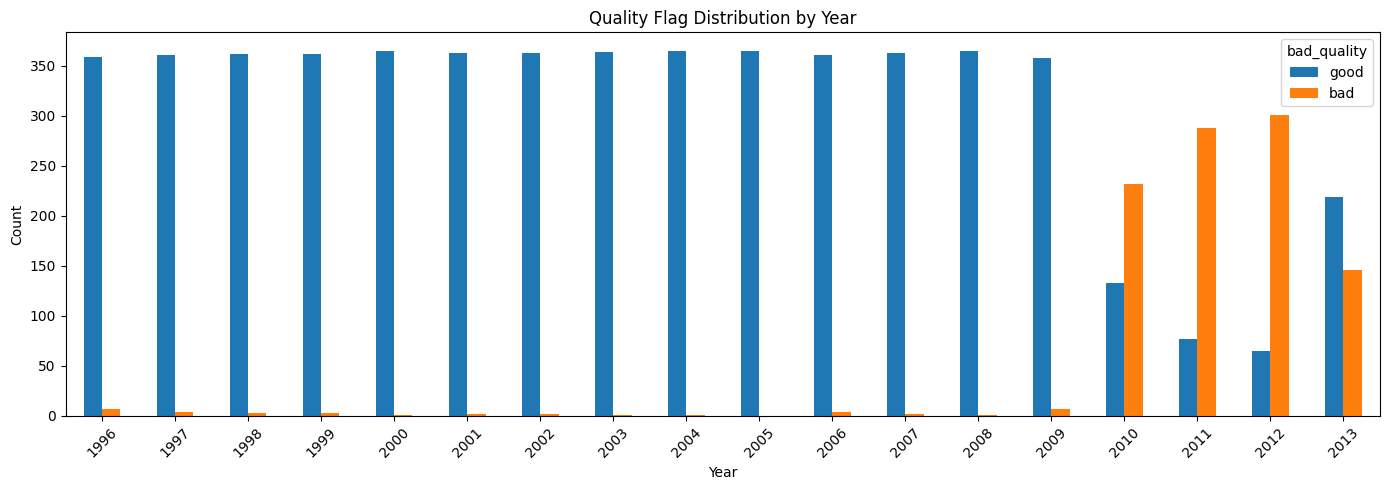

bad_quality,good,bad
year,,
1996,359,7
1997,361,4
1998,362,3
1999,362,3
2000,365,1


In [9]:
solar_df["year"] = solar_df["date"].dt.year

quality_summary = (
    solar_df.groupby(["year", "bad_quality"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "good", 1: "bad"})
)

quality_summary.plot(kind="bar", figsize=(14, 5))

plt.title("Quality Flag Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_quality_by_year.png", dpi=200)
plt.show()

quality_summary.head()

In [10]:
partA_df = clean_df.copy()

partA_df["day_of_year"] = partA_df["date"].dt.dayofyear
partA_df["is_leap_year"] = partA_df["date"].dt.is_leap_year.astype(int)
partA_df["days_in_year"] = np.where(partA_df["is_leap_year"] == 1, 366, 365)

partA_df["day_sin"] = np.sin(2 * np.pi * partA_df["day_of_year"] / partA_df["days_in_year"])
partA_df["day_cos"] = np.cos(2 * np.pi * partA_df["day_of_year"] / partA_df["days_in_year"])

partA_df[["date", "day_of_year", "days_in_year", "day_sin", "day_cos"]].head()

,date,day_of_year,days_in_year,day_sin,day_cos
0,1996-01-01,1,366,0.017166,0.999853
1,1996-01-02,2,366,0.034328,0.999411
2,1996-01-03,3,366,0.051479,0.998674
3,1996-01-04,4,366,0.068615,0.997643
4,1996-01-05,5,366,0.085731,0.996318


In [11]:
partA_df["solar_mean_7d"] = partA_df["solar_t"].rolling(window=7, min_periods=7).mean()
partA_df["solar_std_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
partA_df["solar_min_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).min()
partA_df["solar_max_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).max()

partA_df[[
    "date", "solar_t",
    "solar_mean_7d", "solar_std_7d", "solar_min_7d", "solar_max_7d"
]].head(10)

,date,solar_t,solar_mean_7d,solar_std_7d,solar_min_7d,solar_max_7d
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,NaN,NaN,NaN,NaN
5,1996-01-07,110.547917,NaN,NaN,NaN,NaN
6,1996-01-08,110.200000,83.519387,35.123533,30.275,110.547917
7,1996-01-09,68.202083,88.166114,29.428912,30.275,110.547917
8,1996-01-10,103.577083,87.941709,29.283468,30.275,110.547917
9,1996-01-11,93.595833,86.934268,28.892173,30.275,110.547917


In [12]:
for k in range(1, 8):
    partA_df[f"lag_{k}"] = partA_df["solar_t"].shift(k)

lag_cols = [f"lag_{k}" for k in range(1, 8)]

partA_df[["date", "solar_t"] + lag_cols].head(12)

,date,solar_t,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN
5,1996-01-07,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN
6,1996-01-08,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN
7,1996-01-09,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000
8,1996-01-10,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917
9,1996-01-11,93.595833,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917


In [13]:
for k in range(1, 8):
    partA_df[f"target_t_plus_{k}"] = partA_df["solar_t"].shift(-k)

target_cols = [f"target_t_plus_{k}" for k in range(1, 8)]

partA_df[["date", "solar_t"] + target_cols].tail(12)

,date,solar_t,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
5558,2013-12-14,117.141516,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856
5559,2013-12-15,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591
5560,2013-12-20,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673
5561,2013-12-21,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692
5562,2013-12-22,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057
5563,2013-12-23,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN
5564,2013-12-25,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN
5565,2013-12-27,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN
5566,2013-12-28,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN
5567,2013-12-29,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN,NaN


In [14]:
feature_cols = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + lag_cols

required_cols = feature_cols + target_cols

model_df = partA_df.dropna(subset=required_cols).copy().reset_index(drop=True)

print("partA_df shape:", partA_df.shape)
print("model_df shape:", model_df.shape)
model_df.head()

partA_df shape: (5570, 26)
model_df shape: (5556, 26)


,date,solar_t,bad_quality,day_of_year,is_leap_year,days_in_year,day_sin,day_cos,solar_mean_7d,solar_std_7d,...,lag_5,lag_6,lag_7,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
0,1996-01-09,68.202083,0,9,1,366,0.153891,0.988088,88.166114,29.428912,...,100.647917,105.147917,35.675000,103.577083,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250
1,1996-01-10,103.577083,0,10,1,366,0.170830,0.985301,87.941709,29.283468,...,30.275000,100.647917,105.147917,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750
2,1996-01-11,93.595833,0,11,1,366,0.187719,0.982223,86.934268,28.892173,...,92.141962,30.275000,100.647917,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250
3,1996-01-12,117.706250,0,12,1,366,0.204552,0.978856,99.424447,16.598977,...,110.547917,92.141962,30.275000,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500
4,1996-01-13,119.747917,0,13,1,366,0.221325,0.975200,103.368155,17.815233,...,110.200000,110.547917,92.141962,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500,120.991667


In [15]:
trainval_df = model_df[model_df["date"].dt.year <= 2010].copy().reset_index(drop=True)
test_df = model_df[model_df["date"].dt.year >= 2011].copy().reset_index(drop=True)

val_ratio = 0.20
split_idx = int(len(trainval_df) * (1 - val_ratio))

train_df = trainval_df.iloc[:split_idx].copy().reset_index(drop=True)
val_df = trainval_df.iloc[split_idx:].copy().reset_index(drop=True)

print("Before dropping boundary rows:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

Before dropping boundary rows:
Train: (4161, 26)
Val:   (1041, 26)
Test:  (354, 26)

Date ranges:
Train: 1996-01-09 00:00:00 to 2007-06-28 00:00:00
Val:   2007-06-29 00:00:00 to 2010-12-31 00:00:00
Test:  2011-01-01 00:00:00 to 2013-12-22 00:00:00


In [16]:
val_df = val_df.iloc[7:].copy().reset_index(drop=True)
test_df = test_df.iloc[7:].copy().reset_index(drop=True)

print("After dropping boundary rows:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

After dropping boundary rows:
Train: (4161, 26)
Val:   (1034, 26)
Test:  (347, 26)


In [17]:
X_train = train_df[feature_cols].copy()
X_val   = val_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

y_train = train_df[target_cols].copy()
y_val   = val_df[target_cols].copy()
y_test  = test_df[target_cols].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (4161, 13)
X_val:   (1034, 13)
X_test:  (347, 13)
y_train: (4161, 7)
y_val:   (1034, 7)
y_test:  (347, 7)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_DIR / "feature_scaler.pkl")

print("Scaler saved.")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaler saved.
(4161, 13) (1034, 13) (347, 13)


In [19]:
np.save(OUTPUT_DIR / "X_train.npy", X_train_scaled)
np.save(OUTPUT_DIR / "X_val.npy", X_val_scaled)
np.save(OUTPUT_DIR / "X_test.npy", X_test_scaled)

np.save(OUTPUT_DIR / "y_train.npy", y_train.values)
np.save(OUTPUT_DIR / "y_val.npy", y_val.values)
np.save(OUTPUT_DIR / "y_test.npy", y_test.values)

train_df.to_csv(OUTPUT_DIR / "train_processed.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_processed.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_processed.csv", index=False)

print("Processed files saved.")

Processed files saved.


In [20]:
partA_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "start_date": [train_df["date"].min(), val_df["date"].min(), test_df["date"].min()],
    "end_date": [train_df["date"].max(), val_df["date"].max(), test_df["date"].max()]
})

partA_summary

,split,rows,start_date,end_date
0,train,4161,1996-01-09,2007-06-28
1,val,1034,2007-07-06,2010-12-31
2,test,347,2011-01-26,2013-12-22


## Part B — Multi-Output Model with Custom Loss Functions

A single feedforward multi-output neural network was trained to predict all 7 future horizons simultaneously. The architecture was kept fixed across all experiments:

- input dimension = 13
- hidden layer 1 = 64 ReLU units
- hidden layer 2 = 64 ReLU units
- output layer = 7 linear units

To ensure a fair comparison, the optimiser, learning rate, batch size, early stopping, train/validation/test split, and preprocessing pipeline were held constant. Only the loss function was changed across experiments:

1. Weighted MSE  
2. Pseudo-Huber loss  
3. Weighted Quantile loss  

Performance was evaluated on the test set using horizon-wise RMSE, MAE, MBE, and P95, along with macro-average values across all horizons.

In [21]:
SEED = 42

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [22]:
input_dim = X_train_scaled.shape[1]

def build_model():
    
    model = keras.Sequential([
        
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        
        layers.Dense(7, activation="linear")
        
    ])
    
    return model

In [23]:
horizon_weights = tf.constant([1,2,3,4,5,6,7], dtype=tf.float32)

def weighted_mse(y_true, y_pred):
    
    error = tf.square(y_true - y_pred)
    
    weighted_error = error * horizon_weights
    
    return tf.reduce_mean(weighted_error)

In [24]:
model_mse = build_model()

model_mse.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=weighted_mse
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_mse = model_mse.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


E0000 00:00:1773723122.941775 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - loss: 143355.7344 - val_loss: 60123.3711
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 38724.4922 - val_loss: 30421.5566
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 26073.7734 - val_loss: 22393.5918
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 19413.4355 - val_loss: 16830.4453
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 15915.9199 - val_loss: 14649.5059
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - loss: 14749.1279 - val_loss: 13982.8350
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 14362.6221 - val_loss: 13699.4414
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 14161.5059 - val_loss: 13521.8018
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 14024.7197 - val_loss: 13398.2480
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 13923.9551 - val_loss: 13309.6445
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━

In [25]:
y_pred = model_mse.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE: 61.66744109346216
MAE: 47.88793182373047


In [26]:
def compute_metrics_per_horizon(y_true, y_pred):
    results = []

    for i in range(7):
        yt = y_true.iloc[:, i].values if hasattr(y_true, "iloc") else y_true[:, i]
        yp = y_pred[:, i]

        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)
        mbe = np.mean(yp - yt)
        p95 = np.percentile(np.abs(yp - yt), 95)

        results.append({
            "horizon": f"t+{i+1}",
            "RMSE": rmse,
            "MAE": mae,
            "MBE": mbe,
            "P95": p95
        })

    df_results = pd.DataFrame(results)

    macro_row = pd.DataFrame([{
        "horizon": "macro_avg",
        "RMSE": df_results["RMSE"].mean(),
        "MAE": df_results["MAE"].mean(),
        "MBE": df_results["MBE"].mean(),
        "P95": df_results["P95"].mean()
    }])

    return pd.concat([df_results, macro_row], ignore_index=True)

In [27]:
def train_and_evaluate_model(loss_fn, model_name):
    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred = model.predict(X_test_scaled, verbose=0)
    metrics_df = compute_metrics_per_horizon(y_test, y_pred)

    return model, history, y_pred, metrics_df

In [28]:
def pseudo_huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(
            delta**2 * (tf.sqrt(1.0 + tf.square(error / delta)) - 1.0)
        )
    return loss

In [29]:
model_huber, history_huber, y_pred_huber, metrics_huber = train_and_evaluate_model(
    pseudo_huber_loss(delta=1.0),
    "pseudo_huber"
)

metrics_huber

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 162.6093 - val_loss: 93.8188
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 78.2168 - val_loss: 71.6404
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 65.5186 - val_loss: 60.1614
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - loss: 54.1958 - val_loss: 49.0229
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 46.2918 - val_loss: 43.9032
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - loss: 43.9153 - val_loss: 42.8231
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 43.4214 - val_loss: 42.4347
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 43.1900 - val_loss: 42.2030
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - loss: 43.0390 - val_loss: 42.0422
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 42.9277 - val_loss: 41.9314
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 42.8440 - val_loss: 41.847

E0000 00:00:1773723131.925740 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,60.216707,44.677234,12.336065,125.203533
1,t+2,60.177868,45.300263,8.431295,134.877701
2,t+3,61.548359,46.233984,11.192456,137.566441
3,t+4,61.661001,46.652248,8.398784,138.262520
4,t+5,63.273197,47.692250,10.407280,147.122127
5,t+6,64.782439,48.416463,10.255526,146.875254
6,t+7,65.360152,49.240090,7.709839,148.310972
7,macro_avg,62.431389,46.887505,9.818749,139.745507


In [30]:
def weighted_quantile_loss(q=0.5):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        quantile_part = tf.maximum(q * error, (q - 1.0) * error)
        weighted = quantile_part * horizon_weights
        return tf.reduce_mean(weighted)
    return loss

In [31]:
model_quantile, history_quantile, y_pred_quantile, metrics_quantile = train_and_evaluate_model(
    weighted_quantile_loss(q=0.5),
    "weighted_quantile"
)

metrics_quantile

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 340.7004 - val_loss: 232.6360
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 167.0508 - val_loss: 144.2418
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 132.2170 - val_loss: 123.4107
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - loss: 112.4126 - val_loss: 104.0882
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 97.8714 - val_loss: 93.0104
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 91.5103 - val_loss: 89.1354
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 89.5630 - val_loss: 87.7865
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 88.8290 - val_loss: 87.2430
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - loss: 88.4093 - val_loss: 86.8339
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 88.1161 - val_loss: 86.5640
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - loss: 87.9062 - val_loss:

E0000 00:00:1773723140.302857 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,59.748019,44.544102,11.804455,128.726518
1,t+2,60.594715,45.564708,8.616162,135.819784
2,t+3,61.783998,46.529622,10.891020,138.200845
3,t+4,61.977480,47.037464,7.803385,138.298654
4,t+5,63.557435,47.833317,10.057541,147.410608
5,t+6,64.714538,48.538145,9.200258,146.317328
6,t+7,65.230282,49.063488,7.450938,148.203498
7,macro_avg,62.515209,47.015835,9.403394,140.425319


In [32]:
model_mse, history_mse, y_pred_mse, metrics_mse = train_and_evaluate_model(
    weighted_mse,
    "weighted_mse"
)

metrics_mse

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 146058.5000 - val_loss: 65594.2656
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 40425.7344 - val_loss: 32720.6699
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 28530.1738 - val_loss: 25302.4902
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step - loss: 21842.7715 - val_loss: 18947.9609
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 17089.9102 - val_loss: 15315.0039
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 15055.8096 - val_loss: 14108.8955
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 14397.2988 - val_loss: 13696.7715
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 14143.6680 - val_loss: 13506.8623
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 13997.1250 - val_loss: 13385.8682
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 13897.8076 - val_loss: 13300.5713
Epoch 11/100
131/131 ━━━━━━━━━

,horizon,RMSE,MAE,MBE,P95
0,t+1,58.208714,45.607509,-3.259000,125.962664
1,t+2,59.255338,46.348741,-4.377128,129.443422
2,t+3,60.298039,47.069184,-2.437150,133.864280
3,t+4,61.187335,47.871578,-3.624430,137.096625
4,t+5,62.260137,48.359062,-3.468207,138.188763
5,t+6,63.815129,49.289563,-3.794189,140.159902
6,t+7,65.124744,50.559407,-5.001224,145.051659
7,macro_avg,61.449920,47.872149,-3.708761,135.681045


In [33]:
#The three loss functions produced similar predictive performance, but with small differences across evaluation metrics.
#Overall, Weighted MSE provided the best balance between accuracy and stability for this solar radiation forecasting task.

summary_partB = pd.DataFrame([
    {
        "loss": "Weighted MSE",
        "RMSE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Pseudo-Huber",
        "RMSE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Weighted Quantile",
        "RMSE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "P95"].values[0]
    }
])

summary_partB

,loss,RMSE,MAE,MBE,P95
0,Weighted MSE,61.449920,47.872149,-3.708761,135.681045
1,Pseudo-Huber,62.431389,46.887505,9.818749,139.745507
2,Weighted Quantile,62.515209,47.015835,9.403394,140.425319


In [34]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

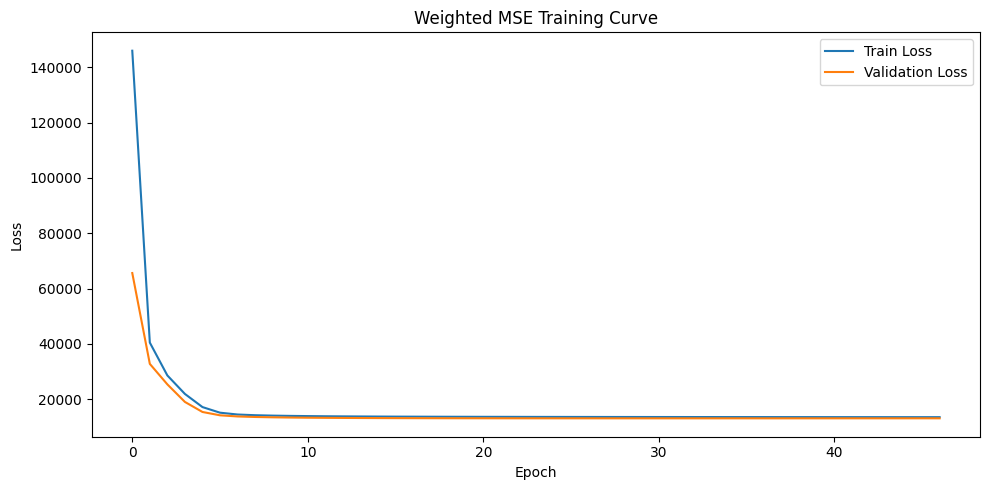

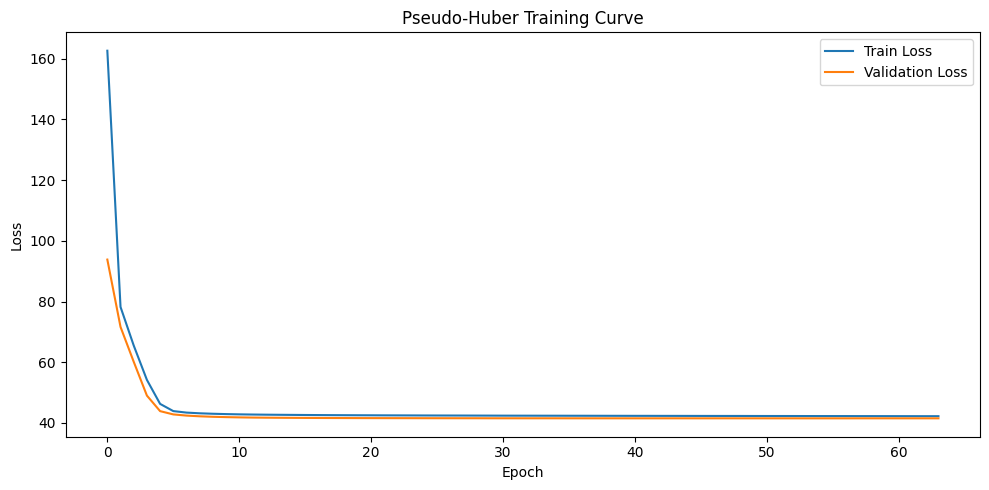

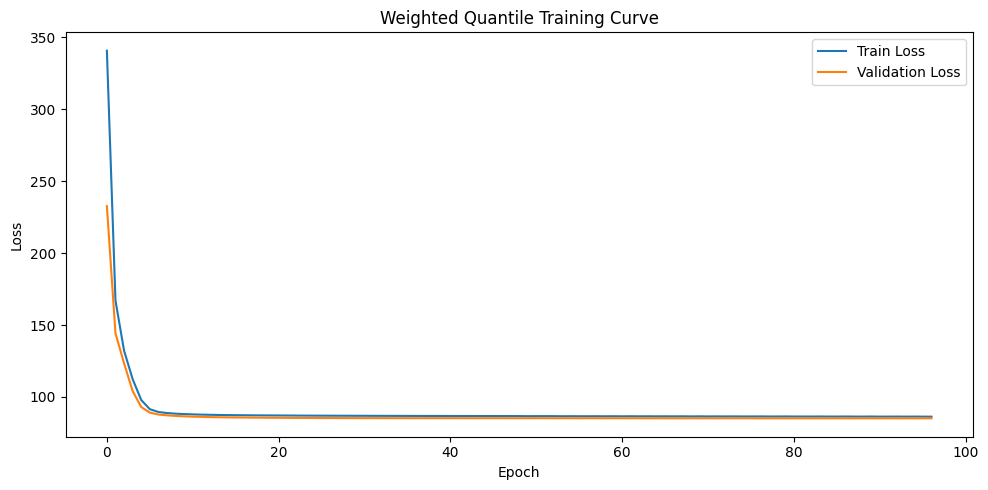

In [35]:
plot_training_history(history_mse, "Weighted MSE Training Curve")
plot_training_history(history_huber, "Pseudo-Huber Training Curve")
plot_training_history(history_quantile, "Weighted Quantile Training Curve")

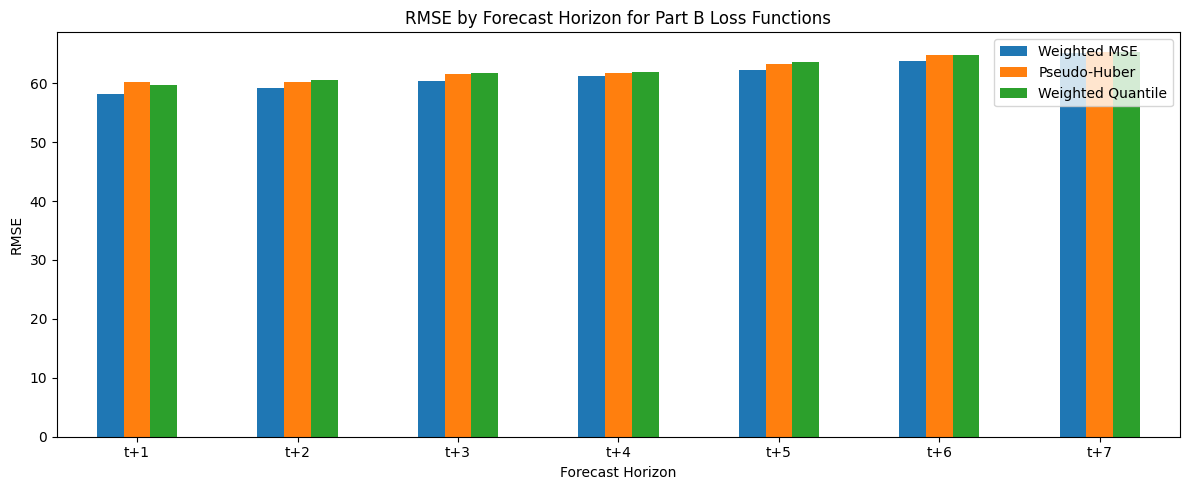

In [36]:
rmse_compare = pd.DataFrame({
    "horizon": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", "horizon"].values,
    "Weighted MSE": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", "RMSE"].values,
    "Pseudo-Huber": metrics_huber.loc[metrics_huber["horizon"] != "macro_avg", "RMSE"].values,
    "Weighted Quantile": metrics_quantile.loc[metrics_quantile["horizon"] != "macro_avg", "RMSE"].values
})

rmse_compare.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE by Forecast Horizon for Part B Loss Functions")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Part C — Individual Models and Transfer Learning

This section compares single-output forecasting models and transfer learning strategies.

The following experiments are implemented:

1. Seven separate single-output models, one for each forecast horizon (t+1 to t+7)
2. Strategy 1 — Sequential Fine-tuning
3. Strategy 2 — Feature Extraction (reported for t+7 only)
4. Strategy 3 — Multi-task Learning with a shared encoder and separate output heads

All models use the same base training setup wherever applicable:
- Adam optimizer
- learning rate = 0.001
- batch size = 32
- early stopping on validation loss

In [37]:
y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

print("y_train_np:", y_train_np.shape)
print("y_val_np:  ", y_val_np.shape)
print("y_test_np: ", y_test_np.shape)

y_train_np: (4161, 7)
y_val_np:   (1034, 7)
y_test_np:  (347, 7)


In [38]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [39]:
def build_single_output_model():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [40]:
independent_results = []
independent_models = []

for horizon in range(7):

    print(f"\nTraining model for horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    model = build_single_output_model()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    independent_results.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "train_time": train_time
    })

    independent_models.append(model)

independent_df = pd.DataFrame(independent_results)
independent_df


Training model for horizon t+1


E0000 00:00:1773723150.402486 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+2

Training model for horizon t+3


E0000 00:00:1773723157.352763 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+4


...


Training model for horizon t+5


E0000 00:00:1773723170.665463 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+6

Training model for horizon t+7


E0000 00:00:1773723179.634712 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,train_time
0,t+1,58.216123,45.047517,5.717649
1,t+2,60.573057,47.166373,2.779482
2,t+3,61.498889,48.096041,4.049453
3,t+4,61.723290,48.623093,7.568553
4,t+5,62.062543,47.928613,5.627586
5,t+6,63.729372,49.286765,3.982857
6,t+7,65.219415,50.638774,4.861640


In [41]:
seq_results = []
previous_model = None

for horizon in range(7):

    print(f"\nSequential training horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    if previous_model is None:
        model = build_single_output_model()
    else:
        model = build_single_output_model()
        model.set_weights(previous_model.get_weights())

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    seq_results.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "train_time": train_time
    })

    previous_model = model

seq_df = pd.DataFrame(seq_results)
seq_df


Sequential training horizon t+1


E0000 00:00:1773723186.791530 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+2


E0000 00:00:1773723191.998670 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+3

Sequential training horizon t+4


E0000 00:00:1773723197.193873 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Sequential training horizon t+5

Sequential training horizon t+6


E0000 00:00:1773723202.623360 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+7


,horizon,RMSE,MAE,train_time
0,t+1,58.125331,45.026374,7.086597
1,t+2,60.148758,46.852421,5.144573
2,t+3,61.562350,47.825253,4.560708
3,t+4,61.587963,48.322601,2.491032
4,t+5,61.487889,47.576348,1.615829
5,t+6,63.334095,48.744228,1.703980
6,t+7,65.107021,50.552489,1.483347


In [42]:
def build_single_output_model_functional():
    inputs = keras.Input(shape=(input_dim,), name="input_layer")
    x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
    x = layers.Dense(64, activation="relu", name="dense_2")(x)
    outputs = layers.Dense(1, name="output_layer")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [43]:
base_model = build_single_output_model_functional()

base_model.fit(
    X_train_scaled,
    y_train_np[:, 0],
    validation_data=(X_val_scaled, y_val_np[:, 0]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0
)

In [44]:
inputs = keras.Input(shape=(input_dim,), name="input_layer")

x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(1, name="new_output_layer")(x)

feature_model = keras.Model(inputs=inputs, outputs=outputs)

In [45]:
feature_model.get_layer("dense_1").set_weights(
    base_model.get_layer("dense_1").get_weights()
)
feature_model.get_layer("dense_2").set_weights(
    base_model.get_layer("dense_2").get_weights()
)

In [46]:
feature_model.get_layer("dense_1").trainable = False
feature_model.get_layer("dense_2").trainable = False

In [47]:
start = time.time()

feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

feature_model.fit(
    X_train_scaled,
    y_train_np[:, 6],
    validation_data=(X_val_scaled, y_val_np[:, 6]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0
)

feature_time = time.time() - start

E0000 00:00:1773723209.996096 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [48]:
y_pred_feature = feature_model.predict(X_test_scaled, verbose=0).flatten()

rmse_feature = np.sqrt(mean_squared_error(y_test_np[:, 6], y_pred_feature))
mae_feature = mean_absolute_error(y_test_np[:, 6], y_pred_feature)

feature_df = pd.DataFrame([{
    "horizon": "t+7",
    "RMSE": rmse_feature,
    "MAE": mae_feature,
    "train_time": feature_time
}])

feature_df

E0000 00:00:1773723217.147175 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,train_time
0,t+7,68.565432,52.851106,7.155078


In [49]:
def build_multitask_model():
    inputs = keras.Input(shape=(input_dim,))

    shared = layers.Dense(64, activation="relu")(inputs)
    shared = layers.Dense(64, activation="relu")(shared)

    outputs = []
    for i in range(7):
        head = layers.Dense(32, activation="relu", name=f"head_hidden_{i+1}")(shared)
        out = layers.Dense(1, name=f"h{i+1}")(head)
        outputs.append(out)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [50]:
multitask_model = build_multitask_model()

start = time.time()

multitask_model.fit(
    X_train_scaled,
    [y_train_np[:, i] for i in range(7)],
    validation_data=(X_val_scaled, [y_val_np[:, i] for i in range(7)]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0
)

multitask_time = time.time() - start

In [51]:
preds = multitask_model.predict(X_test_scaled, verbose=0)

multitask_results = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], preds[i].flatten()))
    mae = mean_absolute_error(y_test_np[:, i], preds[i].flatten())

    multitask_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

multitask_df = pd.DataFrame(multitask_results)
multitask_df

E0000 00:00:1773723223.801685 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.997687,46.721840
1,t+2,59.903039,46.965418
2,t+3,60.667777,47.656661
3,t+4,61.797916,48.608455
4,t+5,63.510054,49.366978
5,t+6,64.993466,50.339069
6,t+7,65.701791,51.150186


In [52]:
partB_baseline_df = metrics_mse[metrics_mse["horizon"] != "macro_avg"][["horizon", "RMSE", "MAE"]].copy()
partB_baseline_df["train_time"] = np.nan
partB_baseline_df

,horizon,RMSE,MAE,train_time
0,t+1,58.208714,45.607509,NaN
1,t+2,59.255338,46.348741,NaN
2,t+3,60.298039,47.069184,NaN
3,t+4,61.187335,47.871578,NaN
4,t+5,62.260137,48.359062,NaN
5,t+6,63.815129,49.289563,NaN
6,t+7,65.124744,50.559407,NaN


In [53]:
comparison_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output RMSE": partB_baseline_df["RMSE"].values,
    "Independent RMSE": independent_df["RMSE"].values,
    "Sequential TL RMSE": seq_df["RMSE"].values,
    "Multitask RMSE": multitask_df["RMSE"].values,
    "Part B Multi-output MAE": partB_baseline_df["MAE"].values,
    "Independent MAE": independent_df["MAE"].values,
    "Sequential TL MAE": seq_df["MAE"].values,
    "Multitask MAE": multitask_df["MAE"].values,
    "Independent train_time": independent_df["train_time"].values,
    "Sequential TL train_time": seq_df["train_time"].values,
})

comparison_df

,horizon,Part B Multi-output RMSE,Independent RMSE,Sequential TL RMSE,Multitask RMSE,Part B Multi-output MAE,Independent MAE,Sequential TL MAE,Multitask MAE,Independent train_time,Sequential TL train_time
0,t+1,58.208714,58.216123,58.125331,58.997687,45.607509,45.047517,45.026374,46.721840,5.717649,7.086597
1,t+2,59.255338,60.573057,60.148758,59.903039,46.348741,47.166373,46.852421,46.965418,2.779482,5.144573
2,t+3,60.298039,61.498889,61.562350,60.667777,47.069184,48.096041,47.825253,47.656661,4.049453,4.560708
3,t+4,61.187335,61.723290,61.587963,61.797916,47.871578,48.623093,48.322601,48.608455,7.568553,2.491032
4,t+5,62.260137,62.062543,61.487889,63.510054,48.359062,47.928613,47.576348,49.366978,5.627586,1.615829
5,t+6,63.815129,63.729372,63.334095,64.993466,49.289563,49.286765,48.744228,50.339069,3.982857,1.703980
6,t+7,65.124744,65.219415,65.107021,65.701791,50.559407,50.638774,50.552489,51.150186,4.861640,1.483347


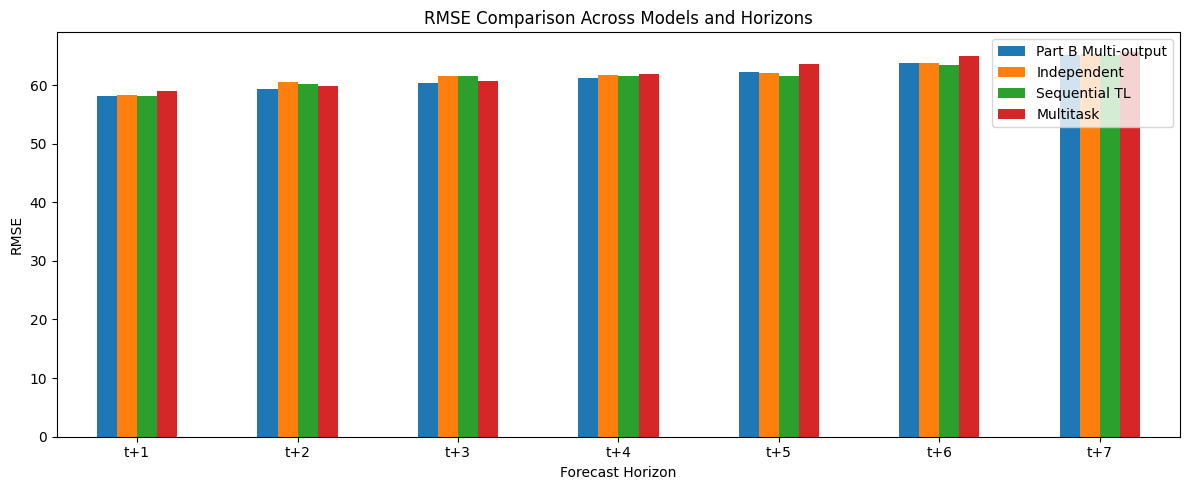

In [54]:
rmse_plot_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output": partB_baseline_df["RMSE"].values,
    "Independent": independent_df["RMSE"].values,
    "Sequential TL": seq_df["RMSE"].values,
    "Multitask": multitask_df["RMSE"].values
})

rmse_plot_df.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE Comparison Across Models and Horizons")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

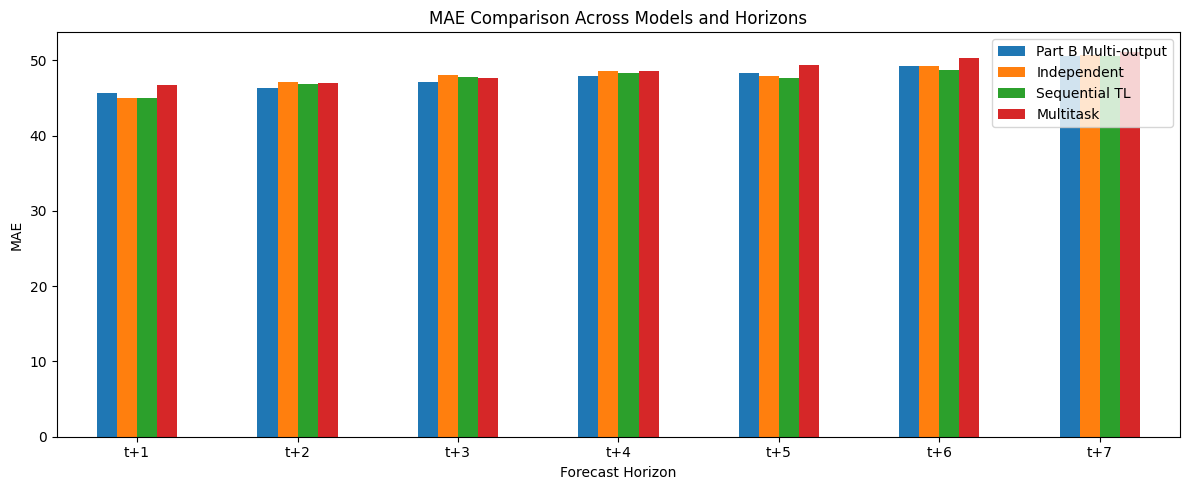

In [55]:
mae_plot_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output": partB_baseline_df["MAE"].values,
    "Independent": independent_df["MAE"].values,
    "Sequential TL": seq_df["MAE"].values,
    "Multitask": multitask_df["MAE"].values
})

mae_plot_df.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("MAE Comparison Across Models and Horizons")
plt.ylabel("MAE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
feature_df

,horizon,RMSE,MAE,train_time
0,t+7,68.565432,52.851106,7.155078


## Part D — Advanced Techniques

### 14. Uncertainty Quantification via Monte Carlo Dropout

To estimate predictive uncertainty, we implement Monte Carlo Dropout. 
Dropout layers are added after each hidden layer of the Part B architecture. 
During inference, dropout remains active and multiple stochastic forward passes are performed.

The predictive mean and variance are estimated using:

μ̂ = (1/T) Σ f_t(x)  
σ̂² = (1/T) Σ (f_t(x) − μ̂)²

where T is the number of stochastic forward passes.

In [57]:
def build_mc_dropout_model():

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [58]:
mc_model = build_mc_dropout_model()

mc_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

In [59]:
T = 50
mc_preds = []

for t in range(T):
    preds = mc_model(X_test_scaled, training=True).numpy()
    mc_preds.append(preds)

mc_preds = np.array(mc_preds)

In [60]:
mc_mean = mc_preds.mean(axis=0)
mc_var = mc_preds.var(axis=0)
mc_std = np.sqrt(mc_var)

In [61]:
mc_results = []

for i in range(7):

    rmse = np.sqrt(mean_squared_error(y_test_np[:,i], mc_mean[:,i]))
    mae = mean_absolute_error(y_test_np[:,i], mc_mean[:,i])

    mc_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

mc_df = pd.DataFrame(mc_results)
mc_df

,horizon,RMSE,MAE
0,t+1,58.392601,45.805928
1,t+2,58.660504,46.014966
2,t+3,60.279413,47.153491
3,t+4,61.104042,47.749776
4,t+5,62.629180,48.774174
5,t+6,63.939813,49.751749
6,t+7,65.407122,50.885755


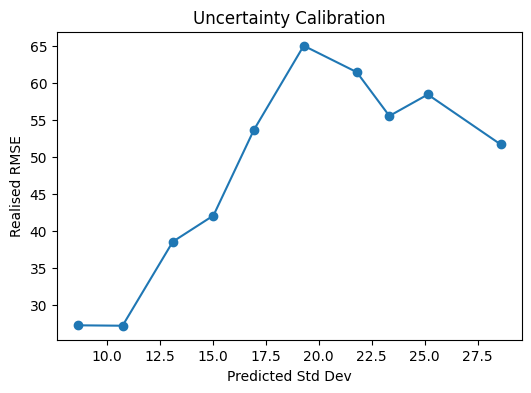

In [62]:
pred_std = mc_std.mean(axis=1)

errors = np.sqrt((mc_mean - y_test_np)**2).mean(axis=1)

bins = pd.qcut(pred_std, q=10)

calibration = pd.DataFrame({
    "std": pred_std,
    "rmse": errors,
    "bin": bins
})

calibration_df = calibration.groupby("bin").mean()

plt.figure(figsize=(6,4))
plt.plot(calibration_df["std"], calibration_df["rmse"], marker="o")
plt.xlabel("Predicted Std Dev")
plt.ylabel("Realised RMSE")
plt.title("Uncertainty Calibration")
plt.show()

### 15. Temporal Attention Mechanism

A temporal attention mechanism is implemented to allow the model to learn 
which lagged time steps are most important for prediction.

The 7 lag features are reshaped into a sequence and attention weights are 
learned using scaled dot-product attention.

The attention output is concatenated with the remaining non-lag features 
before being passed to the output layer.

In [63]:
lag_features = X_train_scaled[:, :7]
other_features = X_train_scaled[:, 7:]

lag_features.shape

(4161, 7)

In [64]:
def build_attention_model_with_scores():
    inputs = keras.Input(shape=(input_dim,), name="full_input")

    # last 7 features are lag_1 ... lag_7 in your Part A feature order
    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lag_seq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lag_seq)
    K = layers.Dense(16, name="K_proj")(lag_seq)
    V = layers.Dense(16, name="V_proj")(lag_seq)

    # scaled dot-product attention scores
    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    context_flat = layers.Flatten(name="attention_flat")(context)

    concat = layers.Concatenate(name="concat_features")([context_flat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="attention_model")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    # second model just for extracting attention weights
    weights_model = keras.Model(inputs=inputs, outputs=weights, name="attention_weights_model")

    return model, weights_model

In [65]:
attention_model, attention_weights_model = build_attention_model_with_scores()

attention_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

E0000 00:00:1773723229.622073 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [66]:
attention_preds = attention_model.predict(X_test_scaled, verbose=0)

attention_results = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], attention_preds[:, i]))
    mae = mean_absolute_error(y_test_np[:, i], attention_preds[:, i])

    attention_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

attention_df = pd.DataFrame(attention_results)
attention_df

E0000 00:00:1773723238.682349 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.694281,46.029682
1,t+2,60.029025,47.137889
2,t+3,61.050235,47.821068
3,t+4,62.164031,48.629173
4,t+5,63.343605,49.367336
5,t+6,64.433230,50.261998
6,t+7,65.593008,51.276070


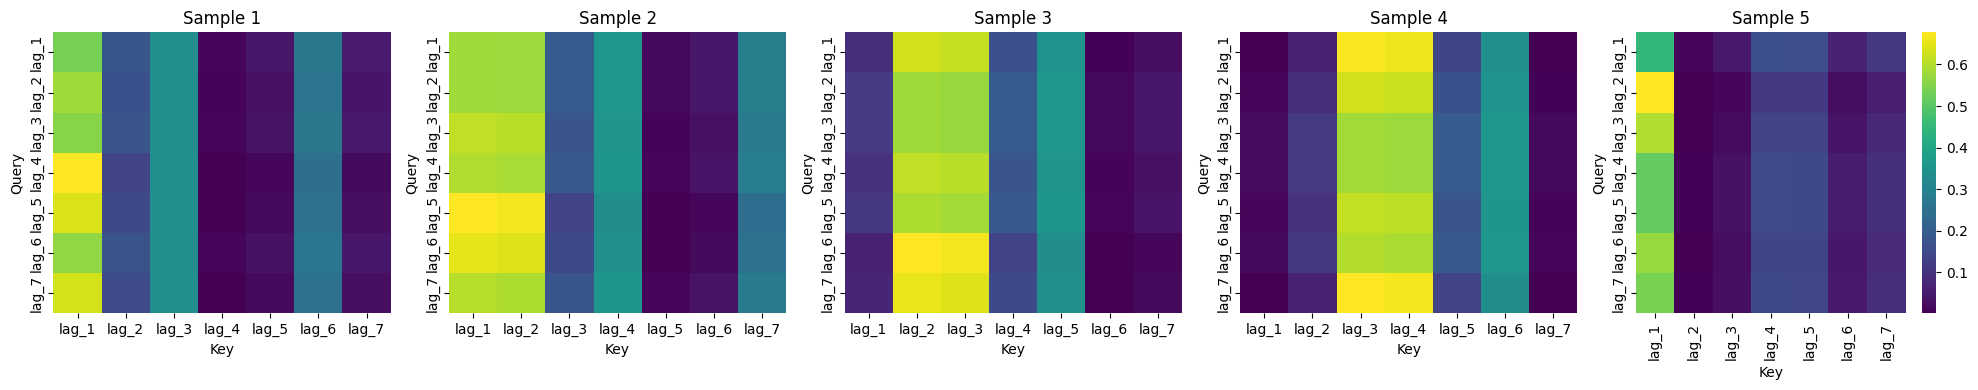

In [67]:
sample = X_test_scaled[:5]
attn_weights = attention_weights_model.predict(sample, verbose=0)   # shape: (5, 7, 7)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    sns.heatmap(
        attn_weights[i],
        ax=axes[i],
        cmap="viridis",
        cbar=(i == 4),
        xticklabels=[f"lag_{j}" for j in range(1, 8)],
        yticklabels=[f"lag_{j}" for j in range(1, 8)]
    )
    axes[i].set_title(f"Sample {i+1}")
    axes[i].set_xlabel("Key")
    axes[i].set_ylabel("Query")

plt.tight_layout()
plt.show()

### 16. Ablation Study

An ablation study is conducted to understand the contribution of different 
feature groups to model performance. Starting from the attention model, 
feature groups are systematically removed and the resulting performance 
degradation is measured.

In [68]:
fourier_idx = [0, 1]
rolling_idx = [2, 3, 4, 5]
lag_idx = [6, 7, 8, 9, 10, 11, 12]

all_idx = list(range(X_train_scaled.shape[1]))

print("All features:", all_idx)
print("Fourier:", fourier_idx)
print("Rolling:", rolling_idx)
print("Lags:", lag_idx)

All features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Fourier: [0, 1]
Rolling: [2, 3, 4, 5]
Lags: [6, 7, 8, 9, 10, 11, 12]


In [69]:
def subset_features(X, keep_idx):
    return X[:, keep_idx]

def build_ffn_multioutput(input_dim_local):
    inputs = keras.Input(shape=(input_dim_local,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return model

def evaluate_macro_metrics(y_true, y_pred):
    rmses = []
    maes = []

    for i in range(7):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmses.append(rmse)
        maes.append(mae)

    return np.mean(rmses), np.mean(maes)

In [70]:
def build_attention_model_with_scores_dynamic(input_dim_local):
    inputs = keras.Input(shape=(input_dim_local,), name="full_input")

    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lag_seq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lag_seq)
    K = layers.Dense(16, name="K_proj")(lag_seq)
    V = layers.Dense(16, name="V_proj")(lag_seq)

    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    context_flat = layers.Flatten(name="attention_flat")(context)
    concat = layers.Concatenate(name="concat_features")([context_flat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    weights_model = keras.Model(inputs=inputs, outputs=weights)

    return model, weights_model

In [71]:
attention_model, attention_weights_model = build_attention_model_with_scores_dynamic(X_train_scaled.shape[1])

attention_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

baseline_preds = attention_model.predict(X_test_scaled, verbose=0)
baseline_rmse, baseline_mae = evaluate_macro_metrics(y_test_np, baseline_preds)

print("Baseline Attention Model")
print("Macro RMSE:", baseline_rmse)
print("Macro MAE:", baseline_mae)

Baseline Attention Model
Macro RMSE: 61.98234083358483
Macro MAE: 48.522103675474575


E0000 00:00:1773723249.014812 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [72]:
keep_no_fourier = [i for i in all_idx if i not in fourier_idx]

X_train_no_fourier = subset_features(X_train_scaled, keep_no_fourier)
X_val_no_fourier = subset_features(X_val_scaled, keep_no_fourier)
X_test_no_fourier = subset_features(X_test_scaled, keep_no_fourier)

model_no_fourier, _ = build_attention_model_with_scores_dynamic(X_train_no_fourier.shape[1])

model_no_fourier.fit(
    X_train_no_fourier,
    y_train_np,
    validation_data=(X_val_no_fourier, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

pred_no_fourier = model_no_fourier.predict(X_test_no_fourier, verbose=0)
rmse_no_fourier, mae_no_fourier = evaluate_macro_metrics(y_test_np, pred_no_fourier)

print("No Fourier - Macro RMSE:", rmse_no_fourier)
print("No Fourier - Macro MAE:", mae_no_fourier)

No Fourier - Macro RMSE: 70.31091874994753
No Fourier - Macro MAE: 53.89684122545019


E0000 00:00:1773723259.623858 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [73]:
keep_no_rolling = [i for i in all_idx if i not in rolling_idx]

X_train_no_rolling = subset_features(X_train_scaled, keep_no_rolling)
X_val_no_rolling = subset_features(X_val_scaled, keep_no_rolling)
X_test_no_rolling = subset_features(X_test_scaled, keep_no_rolling)

model_no_rolling, _ = build_attention_model_with_scores_dynamic(X_train_no_rolling.shape[1])

model_no_rolling.fit(
    X_train_no_rolling,
    y_train_np,
    validation_data=(X_val_no_rolling, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

pred_no_rolling = model_no_rolling.predict(X_test_no_rolling, verbose=0)
rmse_no_rolling, mae_no_rolling = evaluate_macro_metrics(y_test_np, pred_no_rolling)

print("No Rolling - Macro RMSE:", rmse_no_rolling)
print("No Rolling - Macro MAE:", mae_no_rolling)

No Rolling - Macro RMSE: 63.39157269397193
No Rolling - Macro MAE: 49.38309062466114


E0000 00:00:1773723269.947056 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [74]:
keep_no_lags = [i for i in all_idx if i not in lag_idx]

X_train_no_lags = subset_features(X_train_scaled, keep_no_lags)
X_val_no_lags = subset_features(X_val_scaled, keep_no_lags)
X_test_no_lags = subset_features(X_test_scaled, keep_no_lags)

model_no_lags = build_ffn_multioutput(X_train_no_lags.shape[1])

model_no_lags.fit(
    X_train_no_lags,
    y_train_np,
    validation_data=(X_val_no_lags, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

pred_no_lags = model_no_lags.predict(X_test_no_lags, verbose=0)
rmse_no_lags, mae_no_lags = evaluate_macro_metrics(y_test_np, pred_no_lags)

print("No Lags - Macro RMSE:", rmse_no_lags)
print("No Lags - Macro MAE:", mae_no_lags)

No Lags - Macro RMSE: 61.65734662516468
No Lags - Macro MAE: 48.09117778809844


In [75]:
model_no_attention = build_ffn_multioutput(X_train_scaled.shape[1])

model_no_attention.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

pred_no_attention = model_no_attention.predict(X_test_scaled, verbose=0)
rmse_no_attention, mae_no_attention = evaluate_macro_metrics(y_test_np, pred_no_attention)

print("No Attention - Macro RMSE:", rmse_no_attention)
print("No Attention - Macro MAE:", mae_no_attention)

No Attention - Macro RMSE: 61.5556190336819
No Attention - Macro MAE: 48.010682251117096


E0000 00:00:1773723276.804012 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [76]:
ablation_df = pd.DataFrame([
    {"model": "Full Attention Model", "RMSE": baseline_rmse, "MAE": baseline_mae},
    {"model": "Remove Fourier", "RMSE": rmse_no_fourier, "MAE": mae_no_fourier},
    {"model": "Remove Rolling", "RMSE": rmse_no_rolling, "MAE": mae_no_rolling},
    {"model": "Remove Lags", "RMSE": rmse_no_lags, "MAE": mae_no_lags},
    {"model": "Remove Attention", "RMSE": rmse_no_attention, "MAE": mae_no_attention},
])

ablation_df["RMSE_degradation"] = ablation_df["RMSE"] - baseline_rmse
ablation_df["MAE_degradation"] = ablation_df["MAE"] - baseline_mae

ablation_df

,model,RMSE,MAE,RMSE_degradation,MAE_degradation
0,Full Attention Model,61.982341,48.522104,0.000000,0.000000
1,Remove Fourier,70.310919,53.896841,8.328578,5.374738
2,Remove Rolling,63.391573,49.383091,1.409232,0.860987
3,Remove Lags,61.657347,48.091178,-0.324994,-0.430926
4,Remove Attention,61.555619,48.010682,-0.426722,-0.511421


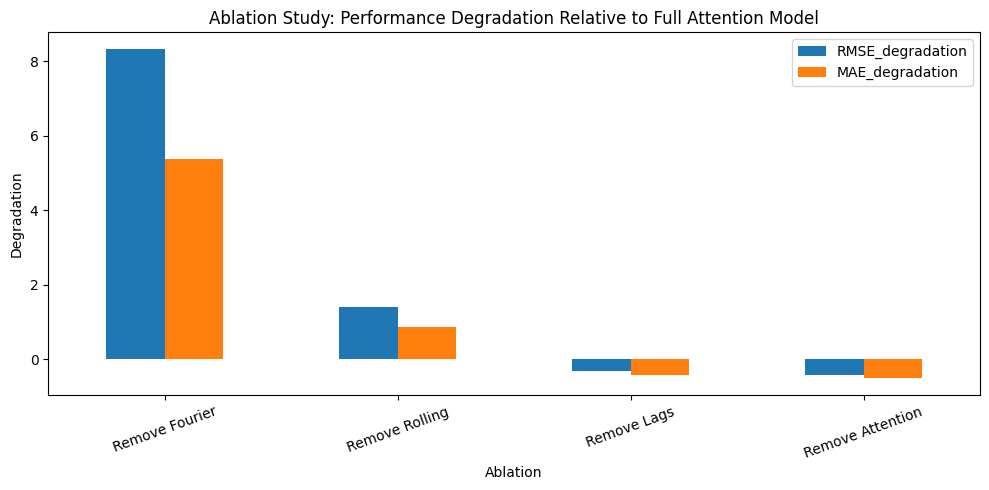

In [77]:
plot_df = ablation_df[ablation_df["model"] != "Full Attention Model"].copy()

plot_df.plot(
    x="model",
    y=["RMSE_degradation", "MAE_degradation"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Performance Degradation Relative to Full Attention Model")
plt.ylabel("Degradation")
plt.xlabel("Ablation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

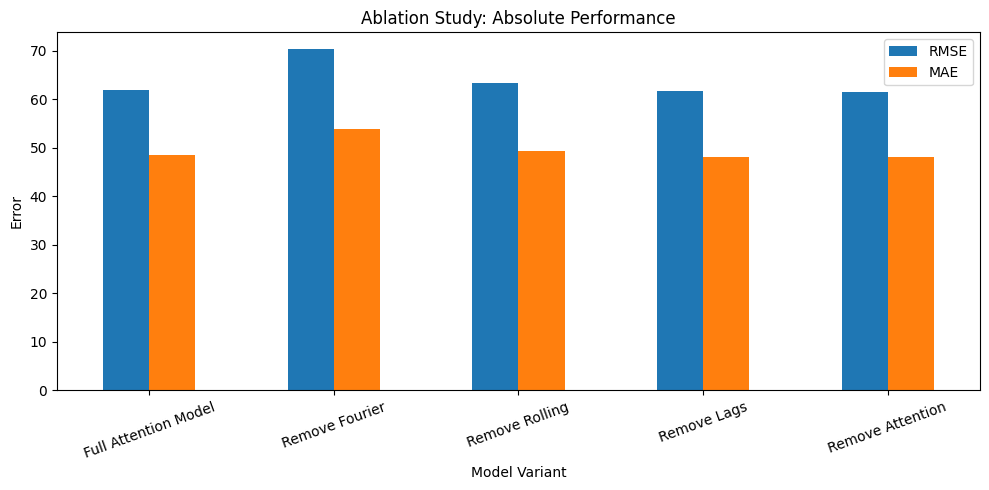

In [78]:
ablation_df.plot(
    x="model",
    y=["RMSE", "MAE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Absolute Performance")
plt.ylabel("Error")
plt.xlabel("Model Variant")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Part E: Statistical Analysis and Discussion

This section evaluates whether performance differences between forecasting models are statistically significant and analyses prediction errors across different environmental and temporal conditions.

In [82]:
from scipy.stats import ttest_rel, t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
partB_model = model_mse

In [84]:
pred_multi = partB_model.predict(X_test_scaled, verbose=0)

pred_individual = np.column_stack([
    independent_models[i].predict(X_test_scaled, verbose=0).flatten()
    for i in range(7)
])

pred_multitask_raw = multitask_model.predict(X_test_scaled, verbose=0)
pred_multitask = np.column_stack([p.flatten() for p in pred_multitask_raw])

pred_attention = attention_model.predict(X_test_scaled, verbose=0)

print("Shapes:")
print("y_test_np      :", y_test_np.shape)
print("pred_multi     :", pred_multi.shape)
print("pred_individual:", pred_individual.shape)
print("pred_multitask :", pred_multitask.shape)
print("pred_attention :", pred_attention.shape)

E0000 00:00:1773723681.506276 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Shapes:
y_test_np      : (347, 7)
pred_multi     : (347, 7)
pred_individual: (347, 7)
pred_multitask : (347, 7)
pred_attention : (347, 7)


In [85]:
mae_multi = np.mean(np.abs(y_test_np - pred_multi), axis=1)
mae_individual = np.mean(np.abs(y_test_np - pred_individual), axis=1)
mae_attention = np.mean(np.abs(y_test_np - pred_attention), axis=1)
mae_multitask = np.mean(np.abs(y_test_np - pred_multitask), axis=1)

print("Daily MAE vector lengths:")
print(len(mae_multi), len(mae_individual), len(mae_attention), len(mae_multitask))

Daily MAE vector lengths:
347 347 347 347


In [86]:
comparisons = {
    "multi-output vs individual": (mae_multi, mae_individual),
    "attention vs multi-output": (mae_attention, mae_multi),
    "multi-output vs multi-task": (mae_multi, mae_multitask),
}

ttest_results = []

for name, (a, b) in comparisons.items():
    diff = a - b
    n = len(diff)

    t_stat, p_value = ttest_rel(a, b)

    mean_diff = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    se_diff = sd_diff / np.sqrt(n)
    t_crit = t.ppf(0.975, df=n - 1)

    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    ttest_results.append({
        "comparison": name,
        "mean_diff": mean_diff,
        "t_statistic": t_stat,
        "p_value": p_value,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,comparison,mean_diff,t_statistic,p_value,ci_95_low,ci_95_high
0,multi-output vs individual,-0.240305,-1.358544,1.751761e-01,-0.588208,0.107598
1,attention vs multi-output,0.649955,2.536889,1.162299e-02,0.146046,1.153863
2,multi-output vs multi-task,-0.814795,-5.536523,6.109441e-08,-1.104249,-0.525340


In [87]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def grouped_error_stats(df, group_col, y_true_cols, y_pred_cols):
    rows = []

    for group_name, g in df.groupby(group_col):
        y_true_g = g[y_true_cols].values
        y_pred_g = g[y_pred_cols].values

        rows.append({
            group_col: group_name,
            "RMSE": rmse(y_true_g, y_pred_g),
            "MAE": mae(y_true_g, y_pred_g)
        })

    return pd.DataFrame(rows)

def plot_grouped_bar(df, category_col, title):
    plot_df = df.set_index(category_col)[["RMSE", "MAE"]]
    plot_df.plot(kind="bar", figsize=(8, 4))
    plt.title(title)
    plt.ylabel("Error")
    plt.xlabel(category_col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [88]:
analysis_df = test_df[["date", "solar_t"]].copy().reset_index(drop=True)

for i in range(7):
    analysis_df[f"y_true_t+{i+1}"] = y_test_np[:, i]
    analysis_df[f"y_pred_t+{i+1}"] = pred_multi[:, i]

analysis_df["daily_rmse_avg7"] = np.sqrt(np.mean((y_test_np - pred_multi) ** 2, axis=1))
analysis_df["daily_mae_avg7"] = np.mean(np.abs(y_test_np - pred_multi), axis=1)

analysis_df.head()

,date,solar_t,y_true_t+1,y_pred_t+1,y_true_t+2,y_pred_t+2,y_true_t+3,y_pred_t+3,y_true_t+4,y_pred_t+4,y_true_t+5,y_pred_t+5,y_true_t+6,y_pred_t+6,y_true_t+7,y_pred_t+7,daily_rmse_avg7,daily_mae_avg7
0,2011-01-26,137.692525,100.465418,114.422485,60.668584,113.988548,166.628151,116.688263,82.132143,117.042221,81.416851,118.553795,113.866370,119.600716,148.104861,120.663864,35.688269,31.777041
1,2011-01-30,100.465418,60.668584,121.880058,166.628151,121.491653,82.132143,123.479439,81.416851,123.864479,113.866370,125.112839,148.104861,126.762535,108.520950,128.389999,38.307599,34.657249
2,2011-01-31,60.668584,166.628151,125.465805,82.132143,125.135155,81.416851,127.526520,113.866370,127.586823,148.104861,129.023911,108.520950,130.775665,180.943450,132.351929,36.012778,33.417524
3,2011-02-02,166.628151,82.132143,128.948395,81.416851,128.855316,113.866370,131.547073,148.104861,131.218216,108.520950,132.376724,180.943450,134.502823,187.222140,135.497635,38.621219,35.834710
4,2011-02-03,82.132143,81.416851,126.247894,113.866370,125.706924,148.104861,128.540314,108.520950,129.012665,180.943450,131.106369,187.222140,131.811340,185.396055,132.940002,40.104207,36.347399


In [89]:
months = pd.to_datetime(analysis_df["date"]).dt.month

def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

analysis_df["season"] = months.map(month_to_season)

y_true_cols = [f"y_true_t+{i+1}" for i in range(7)]
y_pred_cols = [f"y_pred_t+{i+1}" for i in range(7)]

season_stats = grouped_error_stats(analysis_df, "season", y_true_cols, y_pred_cols)
season_stats

,season,RMSE,MAE
0,autumn,58.281109,43.544150
1,spring,82.210323,67.506132
2,summer,59.113595,48.670475
3,winter,45.561187,36.381805


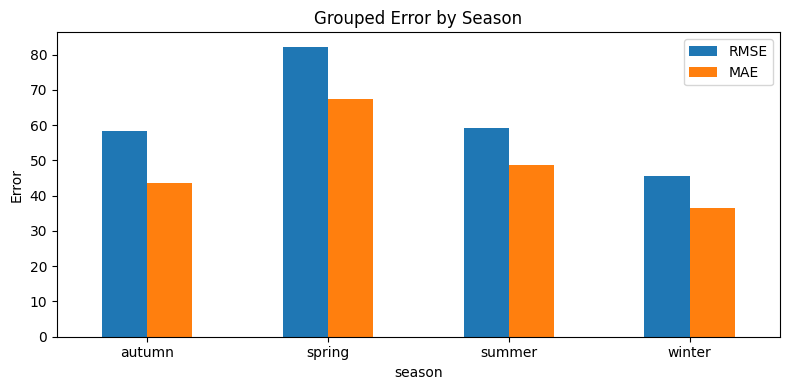

In [90]:
plot_grouped_bar(season_stats, "season", "Grouped Error by Season")

In [91]:
short_true = y_test_np[:, :3]
short_pred = pred_multi[:, :3]

long_true = y_test_np[:, 3:]
long_pred = pred_multi[:, 3:]

horizon_group_df = pd.DataFrame([
    {
        "horizon_group": "short-term",
        "RMSE": rmse(short_true, short_pred),
        "MAE": mae(short_true, short_pred)
    },
    {
        "horizon_group": "long-term",
        "RMSE": rmse(long_true, long_pred),
        "MAE": mae(long_true, long_pred)
    }
])

horizon_group_df

,horizon_group,RMSE,MAE
0,short-term,59.260169,46.341812
1,long-term,63.114613,49.019902


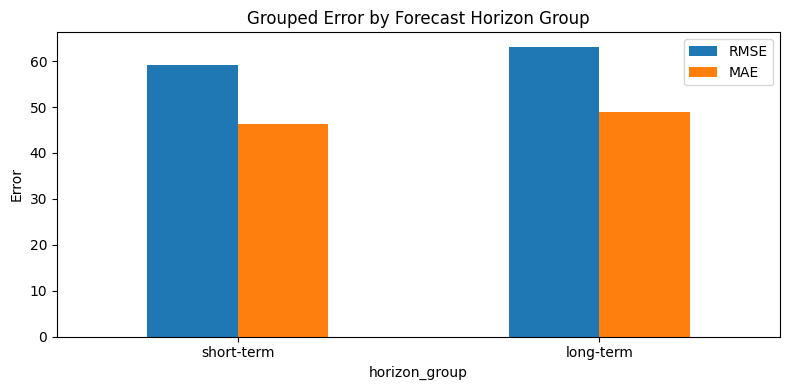

In [92]:
plot_grouped_bar(horizon_group_df, "horizon_group", "Grouped Error by Forecast Horizon Group")

In [93]:
p25 = np.percentile(train_df["solar_t"], 25)
p75 = np.percentile(train_df["solar_t"], 75)

def classify_weather(v):
    if v > p75:
        return "clear"
    elif v < p25:
        return "cloudy"
    else:
        return "mixed"

analysis_df["weather_condition"] = analysis_df["solar_t"].apply(classify_weather)

weather_stats = grouped_error_stats(analysis_df, "weather_condition", y_true_cols, y_pred_cols)
weather_stats

,weather_condition,RMSE,MAE
0,clear,74.254385,61.285769
1,cloudy,43.594830,34.421824
2,mixed,63.110906,48.904694


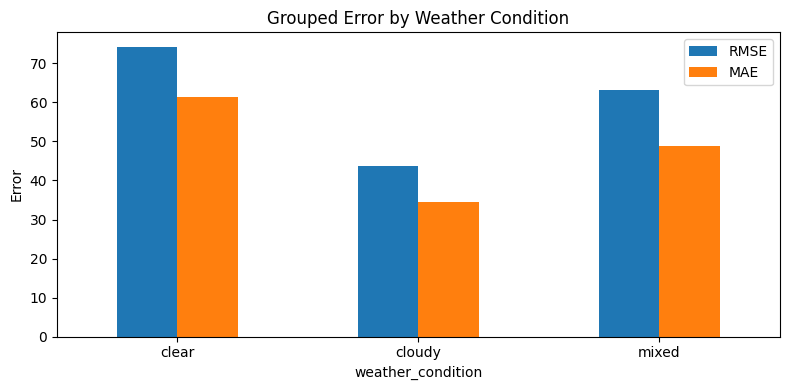

In [94]:
plot_grouped_bar(weather_stats, "weather_condition", "Grouped Error by Weather Condition")

In [95]:
p33 = np.percentile(train_df["solar_t"], 33.3333)
p67 = np.percentile(train_df["solar_t"], 66.6667)

def classify_magnitude(v):
    if v < p33:
        return "low"
    elif v < p67:
        return "medium"
    else:
        return "high"

analysis_df["radiation_magnitude"] = analysis_df["solar_t"].apply(classify_magnitude)

magnitude_stats = grouped_error_stats(analysis_df, "radiation_magnitude", y_true_cols, y_pred_cols)
magnitude_stats

,radiation_magnitude,RMSE,MAE
0,high,74.208621,60.570898
1,low,44.060872,34.349908
2,medium,63.485007,49.687890


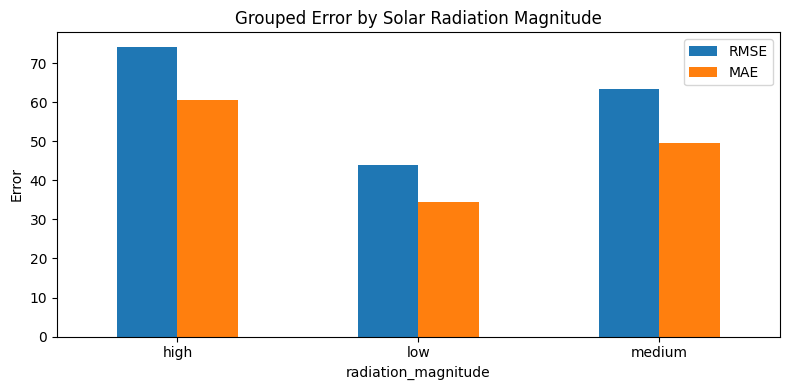

In [96]:
plot_grouped_bar(magnitude_stats, "radiation_magnitude", "Grouped Error by Solar Radiation Magnitude")

In [97]:
analysis_df[[
    "date", "solar_t", "season", "weather_condition", "radiation_magnitude",
    "daily_rmse_avg7", "daily_mae_avg7"
]].head()

,date,solar_t,season,weather_condition,radiation_magnitude,daily_rmse_avg7,daily_mae_avg7
0,2011-01-26,137.692525,winter,mixed,medium,35.688269,31.777041
1,2011-01-30,100.465418,winter,cloudy,low,38.307599,34.657249
2,2011-01-31,60.668584,winter,cloudy,low,36.012778,33.417524
3,2011-02-02,166.628151,winter,mixed,medium,38.621219,35.834710
4,2011-02-03,82.132143,winter,cloudy,low,40.104207,36.347399


## Code to save models

In [98]:
from tensorflow import keras
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
SCALER_DIR = Path("scalers")

MODEL_DIR.mkdir(exist_ok=True)
SCALER_DIR.mkdir(exist_ok=True)

# Part B
model_mse.save(MODEL_DIR / "partB_model_mse.keras")

# Part C
for i, model in enumerate(independent_models, start=1):
    model.save(MODEL_DIR / f"independent_model_t{i}.keras")

# Part C
previous_model.save(MODEL_DIR / "sequential_final_model.keras")

# Part C
multitask_model.save(MODEL_DIR / "multitask_model.keras")

# Part D
mc_model.save(MODEL_DIR / "mc_dropout_model.keras")
attention_model.save(MODEL_DIR / "attention_model.keras")

# scaler
joblib.dump(scaler, SCALER_DIR / "feature_scaler.pkl")

print("Models and scaler saved.")

Models and scaler saved.


## Evaluation Cell

In [108]:
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error

BASE_DIR = Path.cwd()
HIDDEN_DIR = BASE_DIR / "hidden_data"
MODEL_DIR = BASE_DIR / "models"
SCALER_PATH = BASE_DIR / "scalers" / "feature_scaler.pkl"

hidden_files = sorted(glob.glob(str(HIDDEN_DIR / "daily_solar_*.csv")))
print("Hidden files found:", hidden_files)

if len(hidden_files) == 0:
    raise FileNotFoundError("No hidden CSV files found in hidden_data/")

hidden_dfs = []
for file in hidden_files:
    df = pd.read_csv(file)
    hidden_dfs.append(df)

hidden_raw = pd.concat(hidden_dfs, ignore_index=True)
hidden_raw["date"] = pd.to_datetime(hidden_raw["date"])
hidden_raw = hidden_raw.sort_values("date").reset_index(drop=True)

print("Hidden raw shape:", hidden_raw.shape)
hidden_raw.head()

Hidden files found: ["/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_1996.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_1997.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_1998.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_1999.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_2000.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/hidden_data/daily_solar_2001.csv"]
Hidden raw shape: (2192, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


In [109]:
hidden_clean = hidden_raw[hidden_raw["bad_quality"] == 0].copy()
hidden_clean = hidden_clean.sort_values("date").reset_index(drop=True)

hidden_clean["day_of_year"] = hidden_clean["date"].dt.dayofyear
hidden_clean["is_leap_year"] = hidden_clean["date"].dt.is_leap_year.astype(int)
hidden_clean["days_in_year"] = np.where(hidden_clean["is_leap_year"] == 1, 366, 365)

hidden_clean["day_sin"] = np.sin(2 * np.pi * hidden_clean["day_of_year"] / hidden_clean["days_in_year"])
hidden_clean["day_cos"] = np.cos(2 * np.pi * hidden_clean["day_of_year"] / hidden_clean["days_in_year"])

hidden_clean["solar_mean_7d"] = hidden_clean["solar_t"].rolling(window=7, min_periods=7).mean()
hidden_clean["solar_std_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
hidden_clean["solar_min_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).min()
hidden_clean["solar_max_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).max()

for k in range(1, 8):
    hidden_clean[f"lag_{k}"] = hidden_clean["solar_t"].shift(k)

for k in range(1, 8):
    hidden_clean[f"target_t_plus_{k}"] = hidden_clean["solar_t"].shift(-k)

feature_cols = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + [f"lag_{k}" for k in range(1, 8)]

target_cols = [f"target_t_plus_{k}" for k in range(1, 8)]

hidden_model_df = hidden_clean.dropna(subset=feature_cols + target_cols).copy().reset_index(drop=True)

print("Hidden processed shape:", hidden_model_df.shape)
hidden_model_df.head()

Hidden processed shape: (2158, 26)


,date,solar_t,bad_quality,day_of_year,is_leap_year,days_in_year,day_sin,day_cos,solar_mean_7d,solar_std_7d,...,lag_5,lag_6,lag_7,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
0,1996-01-09,68.202083,0,9,1,366,0.153891,0.988088,88.166114,29.428912,...,100.647917,105.147917,35.675000,103.577083,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250
1,1996-01-10,103.577083,0,10,1,366,0.170830,0.985301,87.941709,29.283468,...,30.275000,100.647917,105.147917,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750
2,1996-01-11,93.595833,0,11,1,366,0.187719,0.982223,86.934268,28.892173,...,92.141962,30.275000,100.647917,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250
3,1996-01-12,117.706250,0,12,1,366,0.204552,0.978856,99.424447,16.598977,...,110.547917,92.141962,30.275000,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500
4,1996-01-13,119.747917,0,13,1,366,0.221325,0.975200,103.368155,17.815233,...,110.200000,110.547917,92.141962,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500,120.991667


In [110]:
X_hidden = hidden_model_df[feature_cols].copy()
y_hidden = hidden_model_df[target_cols].copy().values

scaler_loaded = joblib.load(SCALER_PATH)
X_hidden_scaled = scaler_loaded.transform(X_hidden)

print("X_hidden_scaled:", X_hidden_scaled.shape)
print("y_hidden:", y_hidden.shape)

X_hidden_scaled: (2158, 13)
y_hidden: (2158, 7)


In [111]:
partB_model = keras.models.load_model(
    MODEL_DIR / "partB_model_mse.keras",
    custom_objects={"weighted_mse": weighted_mse},
    compile=False
)

attention_model_loaded = attention_model

print("Models ready.")

Models ready.


In [112]:
pred_hidden = partB_model.predict(X_hidden_scaled, verbose=0)

results_hidden = []

for i in range(7):
    rmse_i = np.sqrt(mean_squared_error(y_hidden[:, i], pred_hidden[:, i]))
    mae_i = mean_absolute_error(y_hidden[:, i], pred_hidden[:, i])

    results_hidden.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse_i,
        "MAE": mae_i
    })

hidden_metrics_df = pd.DataFrame(results_hidden)

macro_row = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": hidden_metrics_df["RMSE"].mean(),
    "MAE": hidden_metrics_df["MAE"].mean()
}])

hidden_metrics_df = pd.concat([hidden_metrics_df, macro_row], ignore_index=True)
hidden_metrics_df

E0000 00:00:1773724593.121553 8423540 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,57.546403,43.879449
1,t+2,57.439713,44.009644
2,t+3,57.443747,43.588238
3,t+4,57.447614,43.872981
4,t+5,57.425359,43.819045
5,t+6,57.468676,43.820725
6,t+7,57.647813,44.157683
7,macro_avg,57.488475,43.878252


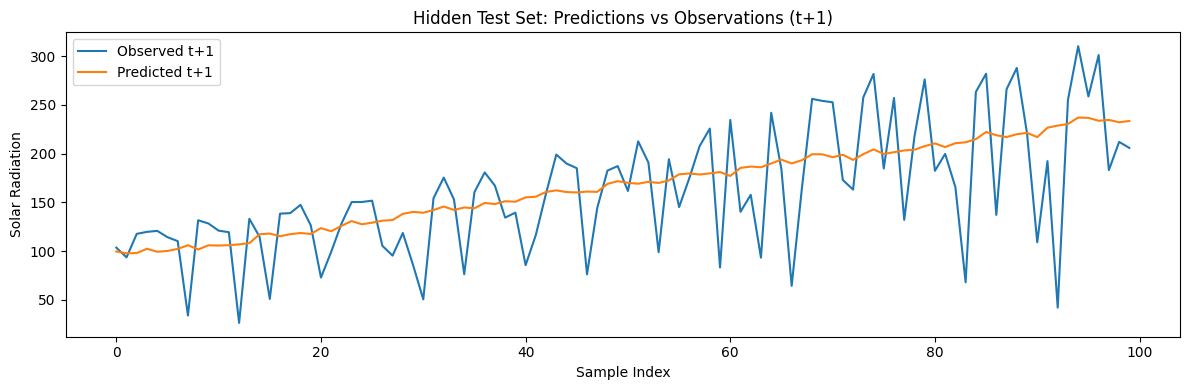

In [113]:
plt.figure(figsize=(12, 4))
plt.plot(y_hidden[:100, 0], label="Observed t+1")
plt.plot(pred_hidden[:100, 0], label="Predicted t+1")
plt.title("Hidden Test Set: Predictions vs Observations (t+1)")
plt.xlabel("Sample Index")
plt.ylabel("Solar Radiation")
plt.legend()
plt.tight_layout()
plt.show()

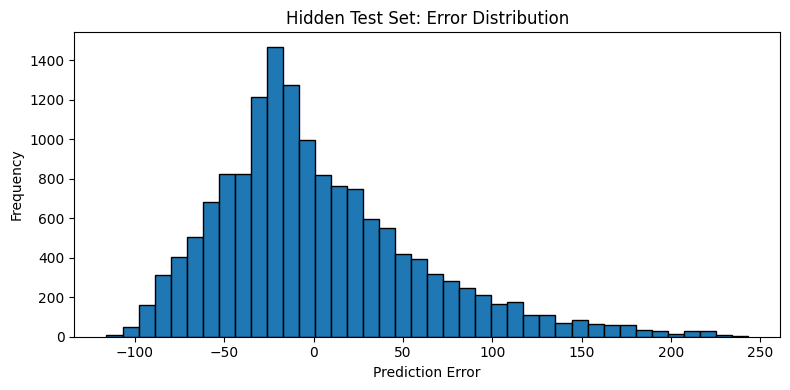

In [114]:
errors_hidden = (pred_hidden - y_hidden).flatten()

plt.figure(figsize=(8, 4))
plt.hist(errors_hidden, bins=40, edgecolor="black")
plt.title("Hidden Test Set: Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [115]:
pred_attention_hidden = attention_model_loaded.predict(X_hidden_scaled, verbose=0)

compare_models_df = []

for name, pred in {
    "PartB_MultiOutput": pred_hidden,
    "Attention": pred_attention_hidden
}.items():
    rmses = []
    maes = []

    for i in range(7):
        rmses.append(np.sqrt(mean_squared_error(y_hidden[:, i], pred[:, i])))
        maes.append(mean_absolute_error(y_hidden[:, i], pred[:, i]))

    compare_models_df.append({
        "model": name,
        "macro_RMSE": np.mean(rmses),
        "macro_MAE": np.mean(maes)
    })

compare_models_df = pd.DataFrame(compare_models_df)
compare_models_df

,model,macro_RMSE,macro_MAE
0,PartB_MultiOutput,57.488475,43.878252
1,Attention,57.569972,44.326074
